## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Interactive maps
import folium
from folium.plugins import HeatMap

import warnings
warnings.filterwarnings('ignore')

**Interpretation:**
* pandas & numpy → for data manipulation
* matplotlib & seaborn → for plots
* folium → to visualize accident hotspots on maps
* warnings → avoid cluttered warning messages

## STEP 2: LOAD DATASET

In [2]:
# Columns to use
cols = ['ID', 'Start_Time', 'End_Time', 'State', 'Severity', 'Start_Lat', 'Start_Lng',
        'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
        'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Sunrise_Sunset', 'Amenity',
        'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Traffic_Signal', 'Turning_Loop']

# Load a subset for analysis
df = pd.read_csv("US_Accidents_March23.csv", usecols=cols, nrows=200000, parse_dates=['Start_Time', 'End_Time'])

# Preview the data
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,State,Temperature(F),Humidity(%),Pressure(in),...,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Traffic_Signal,Turning_Loop,Sunrise_Sunset
0,A-1,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,OH,36.9,91.0,29.68,...,False,False,False,False,False,False,False,False,False,Night
1,A-2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,OH,37.9,100.0,29.65,...,False,False,False,False,False,False,False,False,False,Night
2,A-3,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,OH,36.0,100.0,29.67,...,False,False,False,False,False,False,False,True,False,Night
3,A-4,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,OH,35.1,96.0,29.64,...,False,False,False,False,False,False,False,False,False,Night
4,A-5,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,OH,36.0,89.0,29.65,...,False,False,False,False,False,False,False,True,False,Day


**Interpretation:**
* We’re only loading relevant columns (location, weather, road conditions, and severity).
* parse_dates converts Start_Time and End_Time to datetime for time analysis.

## STEP 3: BASIC EDA AND DATA CLEANING

### 3.1 Check Shape and Info

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Info:\n")
df.info()

Dataset Shape: (200000, 26)

Column Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 200000 non-null  object        
 1   Severity           200000 non-null  int64         
 2   Start_Time         200000 non-null  datetime64[ns]
 3   End_Time           200000 non-null  datetime64[ns]
 4   Start_Lat          200000 non-null  float64       
 5   Start_Lng          200000 non-null  float64       
 6   State              200000 non-null  object        
 7   Temperature(F)     197165 non-null  float64       
 8   Humidity(%)        196757 non-null  float64       
 9   Pressure(in)       197797 non-null  float64       
 10  Visibility(mi)     196737 non-null  float64       
 11  Wind_Speed(mph)    161560 non-null  float64       
 12  Precipitation(in)  18352 non-null   float64       
 13  W

### 3.2 Check Missing Values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)
missing_data = pd.DataFrame({'Missing': missing, 'Percent': missing_percent})
print(missing_data.head(10))

                   Missing  Percent
Precipitation(in)   181648    90.82
Wind_Speed(mph)      38440    19.22
Visibility(mi)        3263     1.63
Humidity(%)           3243     1.62
Temperature(F)        2835     1.42
Weather_Condition     2788     1.39
Pressure(in)          2203     1.10
Sunrise_Sunset          14     0.01
Severity                 0     0.00
ID                       0     0.00


**Interpretation:**
* Some columns like Temperature, Wind_Speed may have missing values.
* We will fill them with median values later for analysis.

### 3.3 Fill/Handle Missing Values

In [5]:
# Fill numerical columns with median
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with 'Unknown'
cat_cols = ['Weather_Condition', 'Sunrise_Sunset']
for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)

**Interpretation:**
* Missing numerical values were filled with the median
* Categorical ones with “Unknown”
* Ensures the dataset is complete and ready for accurate analysis without dropping any records

### 3.4 Add Useful Columns(Data Extraction)

In [6]:
# Extract hour, day, weekday, month
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month

**Interpretation:**
* We extracted hour, weekday, and month from the start time.
* To analyze time-based patterns in accidents (like rush hours, weekdays vs weekends, and seasonal trends).

## STEP 4: ANALYZE TRAFFICACCIDENT PATTERNS

### 4.1 Accident Severity Distribution

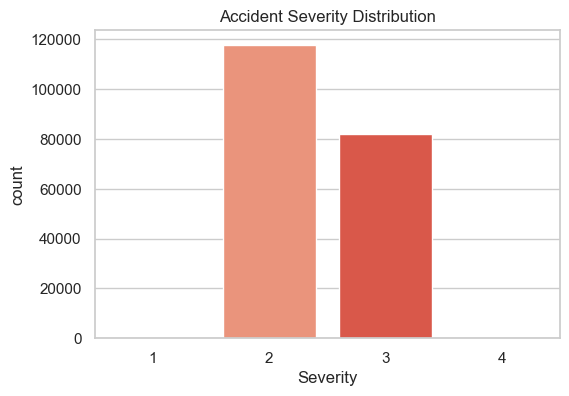

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Severity', data=df, palette='Reds')
plt.title("Accident Severity Distribution")
plt.show()

**Interpretation:**
* Severity ranges from 1 (minor) to 4 (major).
* Most accidents are likely minor (Severity 2).

### 4.2 Accidents by State

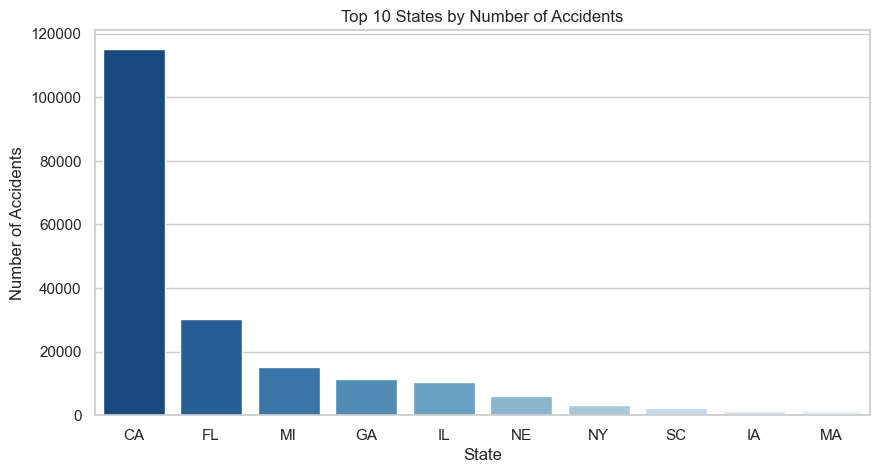

In [8]:
state_counts = df['State'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='Blues_r')
plt.title("Top 10 States by Number of Accidents")
plt.ylabel("Number of Accidents")
plt.show()

**Interpretation:**
* States with dense population or high traffic tend to have more accidents.
* Here, California

### 4.3 Accidents by Hour of Day

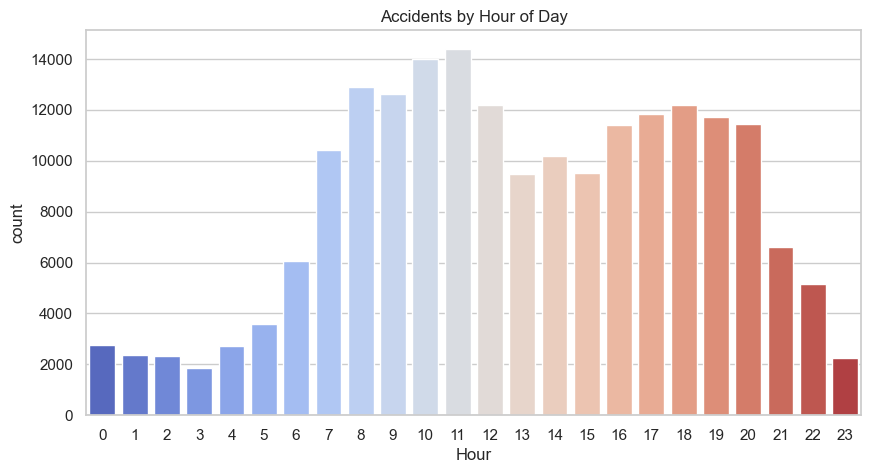

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df, palette='coolwarm')
plt.title("Accidents by Hour of Day")
plt.show()

**Interpretation:**
* Peaks usually occur during morning (7-9AM) and evening (4-7PM) rush hours.

### 4.4 Accidents by Weather Condition

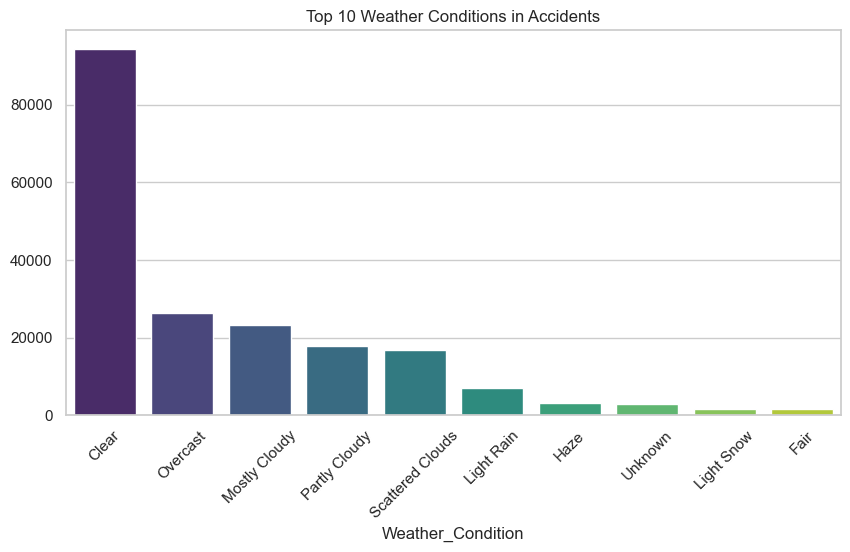

In [10]:
top_weather = df['Weather_Condition'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_weather.index, y=top_weather.values, palette='viridis')
plt.xticks(rotation=45)
plt.title("Top 10 Weather Conditions in Accidents")
plt.show()

**Interpretation:**
* Most accidents occur during clear or cloudy weather because these are the most common conditions.
* Rain, snow, or fog increases severity relative to frequency.

### 4.5 Road Conditions and Traffic Features

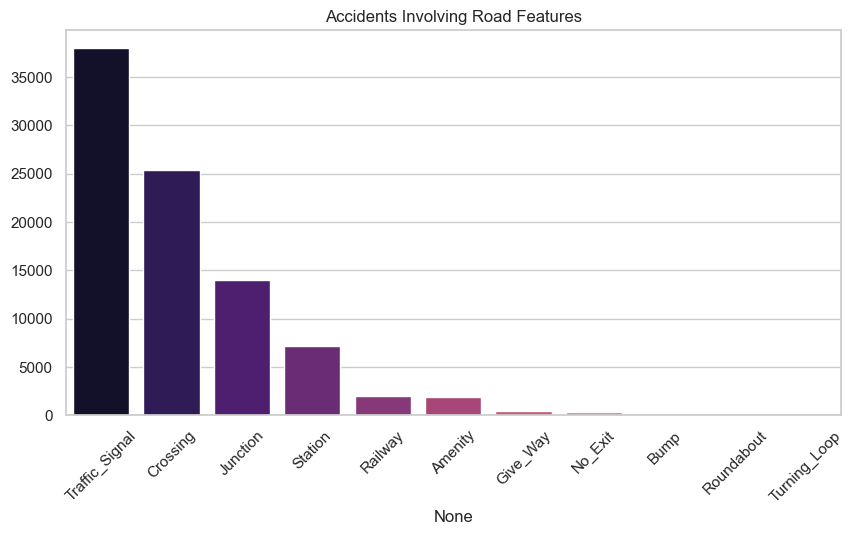

In [11]:
road_features = ['Amenity','Bump','Crossing','Give_Way','Junction','No_Exit','Railway','Roundabout','Station','Traffic_Signal','Turning_Loop']
road_summary = df[road_features].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=road_summary.index, y=road_summary.values, palette='magma')
plt.title("Accidents Involving Road Features")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**
* Features like Junctions and Traffic Signals are common accident points.
* Road design influences accident risk.

### 4.6 Heatmap of Accidents (Hotspots)

In [12]:
# Use subset for faster map plotting
map_data = df[['Start_Lat','Start_Lng']].dropna().sample(5000)

accident_map = folium.Map(location=[map_data['Start_Lat'].mean(), map_data['Start_Lng'].mean()],
                          zoom_start=5)

HeatMap(data=map_data, radius=8).add_to(accident_map)
accident_map

**Interpretation:**
* Dense hotspots show areas with high accident concentration.
* Useful for traffic management and urban planning.

## STEP 5: INSIGHTS FROM ANALYSIS

1. **Severity & Timing:** Most accidents are minor; peaks during rush hours.
  
2. **Weather:** Clear weather sees most accidents (due to frequency), but rain/fog increases severity.
  
3. **State Patterns:** Higher accident counts in densely populated states.
  
4. **Road Features:** Junctions, traffic signals, and roundabouts are critical hotspots.
  
5. **Spatial Hotspots:** Heatmaps identify areas for targeted safety measures.